## Install dependencies (run once, then restart kernel)

In [3]:
import sys
!{sys.executable} -m pip install numpy nibabel matplotlib torch tqdm

Defaulting to user installation because normal site-packages is not writeable


## Imports and global settings

In [6]:
import os
import random
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Conference-paper global settings ─────────────────────────────────────────
FONT_SIZE  = 20
DPI        = 600
OUTPUT_DIR = "conference_figures_dataset"
os.makedirs(OUTPUT_DIR, exist_ok=True)

matplotlib.rcParams.update({
    'font.size':        FONT_SIZE,
    'axes.labelsize':   FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize':  FONT_SIZE,
    'ytick.labelsize':  FONT_SIZE,
    'font.weight':      'bold',
    'axes.titlesize':   FONT_SIZE,
    'axes.titleweight': 'bold',
})

def make_bold_ticks(ax):
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
        lbl.set_fontsize(FONT_SIZE)

def save_fig(fig, fname):
    path = os.path.join(OUTPUT_DIR, fname)
    fig.savefig(path, dpi=DPI, bbox_inches='tight')
    print(f"Saved → {path}")

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
preprocessed_path = "preprocessed"
save_dir_imgs     = os.path.join(preprocessed_path, "imagesTr")
save_dir_lbls     = os.path.join(preprocessed_path, "labelsTr")

all_images = sorted([f for f in os.listdir(save_dir_imgs)
                     if f.endswith('.nii.gz') and not f.startswith('.')])
all_labels = sorted([f for f in os.listdir(save_dir_lbls)
                     if f.endswith('.nii.gz') and not f.startswith('.')])

print(f"Total cases     : {len(all_images)}")
print(f"Output figures  : {os.path.abspath(OUTPUT_DIR)}")
print(f"DPI={DPI}  FontSize={FONT_SIZE}")

Total cases     : 126
Output figures  : C:\Users\DYPIU\Downloads\COLON\conference_figures_dataset
DPI=600  FontSize=20


## Train / validation split

In [7]:
combined = list(zip(all_images, all_labels))
random.shuffle(combined)
all_images_shuffled, all_labels_shuffled = zip(*combined)

train_imgs = list(all_images_shuffled[:100])
train_lbls = list(all_labels_shuffled[:100])
val_imgs   = list(all_images_shuffled[100:])
val_lbls   = list(all_labels_shuffled[100:])

print(f"Training cases  : {len(train_imgs)}")
print(f"Validation cases: {len(val_imgs)}")
print(f"\nFirst 5 training : {train_imgs[:5]}")
print(f"First 5 val      : {val_imgs[:5]}")

Training cases  : 100
Validation cases: 26

First 5 training : ['colon_022.nii.gz', 'colon_157.nii.gz', 'colon_171.nii.gz', 'colon_136.nii.gz', 'colon_095.nii.gz']
First 5 val      : ['colon_042.nii.gz', 'colon_127.nii.gz', 'colon_193.nii.gz', 'colon_137.nii.gz', 'colon_117.nii.gz']


## Define patch extraction functions

In [8]:
PATCH_SIZE = (128, 128, 128)

def get_random_patch(image, label, patch_size=PATCH_SIZE):
    x, y, z   = image.shape
    px, py, pz = patch_size
    x_s = random.randint(0, max(0, x - px))
    y_s = random.randint(0, max(0, y - py))
    z_s = random.randint(0, max(0, z - pz))
    return image[x_s:x_s+px, y_s:y_s+py, z_s:z_s+pz],            label[x_s:x_s+px, y_s:y_s+py, z_s:z_s+pz]

def get_tumor_patch(image, label, patch_size=PATCH_SIZE):
    px, py, pz   = patch_size
    tumor_coords = np.argwhere(label == 1)
    if len(tumor_coords) == 0:
        return get_random_patch(image, label, patch_size)
    center = tumor_coords[random.randint(0, len(tumor_coords)-1)]
    cx, cy, cz = center
    x_s = int(np.clip(cx - px//2, 0, max(0, image.shape[0] - px)))
    y_s = int(np.clip(cy - py//2, 0, max(0, image.shape[1] - py)))
    z_s = int(np.clip(cz - pz//2, 0, max(0, image.shape[2] - pz)))
    return image[x_s:x_s+px, y_s:y_s+py, z_s:z_s+pz],            label[x_s:x_s+px, y_s:y_s+py, z_s:z_s+pz]

def pad_if_needed(image, label, patch_size=PATCH_SIZE):
    px, py, pz = patch_size
    x, y, z    = image.shape
    pad = [(0, max(0, p - s)) for p, s in zip((px, py, pz), (x, y, z))]
    if any(p[1] > 0 for p in pad):
        image = np.pad(image, pad, mode='constant', constant_values=0)
        label = np.pad(label, pad, mode='constant', constant_values=0)
    return image, label

# Quick test
test_img = nib.load(os.path.join(save_dir_imgs, train_imgs[0])).get_fdata()
test_lbl = nib.load(os.path.join(save_dir_lbls, train_lbls[0])).get_fdata()
test_img, test_lbl = pad_if_needed(test_img, test_lbl)

rand_img,  rand_lbl  = get_random_patch(test_img, test_lbl)
tumor_img, tumor_lbl = get_tumor_patch (test_img, test_lbl)

print(f"Volume shape        : {test_img.shape}")
print(f"Random patch shape  : {rand_img.shape}")
print(f"Tumor patch shape   : {tumor_img.shape}")
print(f"Tumor voxels random : {int(rand_lbl.sum())}")
print(f"Tumor voxels tumor  : {int(tumor_lbl.sum())}")

Volume shape        : (274, 274, 380)
Random patch shape  : (128, 128, 128)
Tumor patch shape   : (128, 128, 128)
Tumor voxels random : 0
Tumor voxels tumor  : 16725


## Define augmentation functions

In [9]:
def augment_patch(image, label):
    # Random flips
    for ax in range(3):
        if random.random() > 0.5:
            image = np.flip(image, axis=ax).copy()
            label = np.flip(label, axis=ax).copy()
    # Random 90° rotation
    k = random.randint(0, 3)
    if k > 0:
        image = np.rot90(image, k=k, axes=(0,1)).copy()
        label = np.rot90(label, k=k, axes=(0,1)).copy()
    # Intensity scale
    if random.random() > 0.5:
        image = image * random.uniform(0.9, 1.1)
    # Intensity shift
    if random.random() > 0.5:
        image = image + random.uniform(-0.1, 0.1)
    # Gaussian noise
    if random.random() > 0.5:
        image = image + np.random.normal(0, 0.05, image.shape)
    return image, label

aug_img, aug_lbl = augment_patch(tumor_img.copy(), tumor_lbl.copy())
print(f"Before — mean:{tumor_img.mean():.3f}  std:{tumor_img.std():.3f}")
print(f"After  — mean:{aug_img.mean():.3f}  std:{aug_img.std():.3f}")
print(f"Label values preserved : {np.unique(aug_lbl)}")
print(f"Tumor voxels preserved : {int(aug_lbl.sum())}  (orig: {int(tumor_lbl.sum())})")

Before — mean:-0.223  std:1.165
After  — mean:-0.219  std:1.147
Label values preserved : [0. 1.]
Tumor voxels preserved : 16725  (orig: 16725)


## PyTorch Dataset class (on-the-fly loading)

In [10]:
class ColonDataset(Dataset):
    """On-the-fly patch dataset with tumor-focused sampling and augmentation."""

    def __init__(self, image_files, label_files,
                 img_dir, lbl_dir,
                 patch_size=(128,128,128),
                 patches_per_volume=4,
                 tumor_sampling_ratio=0.67,
                 augment=True):

        self.image_files          = image_files
        self.label_files          = label_files
        self.img_dir              = img_dir
        self.lbl_dir              = lbl_dir
        self.patch_size           = patch_size
        self.patches_per_volume   = patches_per_volume
        self.tumor_sampling_ratio = tumor_sampling_ratio
        self.augment              = augment

        print("Caching tumour locations...")
        self.tumor_coords = []
        for fname_lbl in tqdm(label_files):
            lbl    = nib.load(os.path.join(lbl_dir, fname_lbl)).get_fdata().astype(np.float32)
            coords = np.argwhere(lbl == 1)
            self.tumor_coords.append(coords)
        print(f"Done. {len(self.tumor_coords)} volumes indexed.")

    def __len__(self):
        return len(self.image_files) * self.patches_per_volume

    def __getitem__(self, idx):
        vol_idx = idx % len(self.image_files)
        img = nib.load(os.path.join(self.img_dir, self.image_files[vol_idx])).get_fdata().astype(np.float32)
        lbl = nib.load(os.path.join(self.lbl_dir, self.label_files[vol_idx])).get_fdata().astype(np.float32)
        img, lbl = pad_if_needed(img, lbl, self.patch_size)

        if random.random() < self.tumor_sampling_ratio:
            img_patch, lbl_patch = get_tumor_patch(img, lbl, self.patch_size)
        else:
            img_patch, lbl_patch = get_random_patch(img, lbl, self.patch_size)

        if self.augment:
            img_patch, lbl_patch = augment_patch(img_patch, lbl_patch)

        img_tensor = torch.from_numpy(img_patch).float().unsqueeze(0)
        lbl_tensor = torch.from_numpy(lbl_patch).float().unsqueeze(0)
        return img_tensor, lbl_tensor

print("ColonDataset class defined.")

ColonDataset class defined.


## Create datasets and DataLoaders

In [11]:
print("Creating training dataset...")
train_dataset = ColonDataset(
    image_files=train_imgs, label_files=train_lbls,
    img_dir=save_dir_imgs,  lbl_dir=save_dir_lbls,
    patch_size=(128,128,128), patches_per_volume=4,
    tumor_sampling_ratio=0.67, augment=True
)

print("\nCreating validation dataset...")
val_dataset = ColonDataset(
    image_files=val_imgs, label_files=val_lbls,
    img_dir=save_dir_imgs, lbl_dir=save_dir_lbls,
    patch_size=(128,128,128), patches_per_volume=4,
    tumor_sampling_ratio=0.67, augment=False
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

print(f"\nTrain volumes       : {len(train_imgs)}")
print(f"Val volumes         : {len(val_imgs)}")
print(f"Train patches/epoch : {len(train_dataset)}")
print(f"Val patches/epoch   : {len(val_dataset)}")
print(f"Train batches       : {len(train_loader)}")
print(f"Val batches         : {len(val_loader)}")

Creating training dataset...
Caching tumour locations...


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:37<00:00,  1.03it/s]


Done. 100 volumes indexed.

Creating validation dataset...
Caching tumour locations...


100%|██████████████████████████████████████████████████████████████████████████████████| 26/26 [00:26<00:00,  1.02s/it]

Done. 26 volumes indexed.

Train volumes       : 100
Val volumes         : 26
Train patches/epoch : 400
Val patches/epoch   : 104
Train batches       : 200
Val batches         : 104


## Test DataLoader — fetch one batch

In [12]:
import time
print("Fetching one training batch...")
start = time.time()
img_batch, lbl_batch = next(iter(train_loader))
elapsed = time.time() - start

print(f"Batch load time     : {elapsed:.1f} s")
print(f"Image batch shape   : {img_batch.shape}")
print(f"Label batch shape   : {lbl_batch.shape}")
print(f"Image min/max       : {img_batch.min():.3f} / {img_batch.max():.3f}")
print(f"Label unique values : {lbl_batch.unique()}")
print(f"Tumour voxels batch : {(lbl_batch == 1).sum().item()}")

Fetching one training batch...


C:\Users\DYPIU\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch load time     : 4.2 s
Image batch shape   : torch.Size([2, 1, 128, 128, 128])
Label batch shape   : torch.Size([2, 1, 128, 128, 128])
Image min/max       : -1.465 / 3.548
Label unique values : tensor([0., 1.])
Tumour voxels batch : 45745


## Fig 1 – Training batch: CT patch, label, overlay (6-panel)

Saved → conference_figures_dataset\fig1_training_batch.png


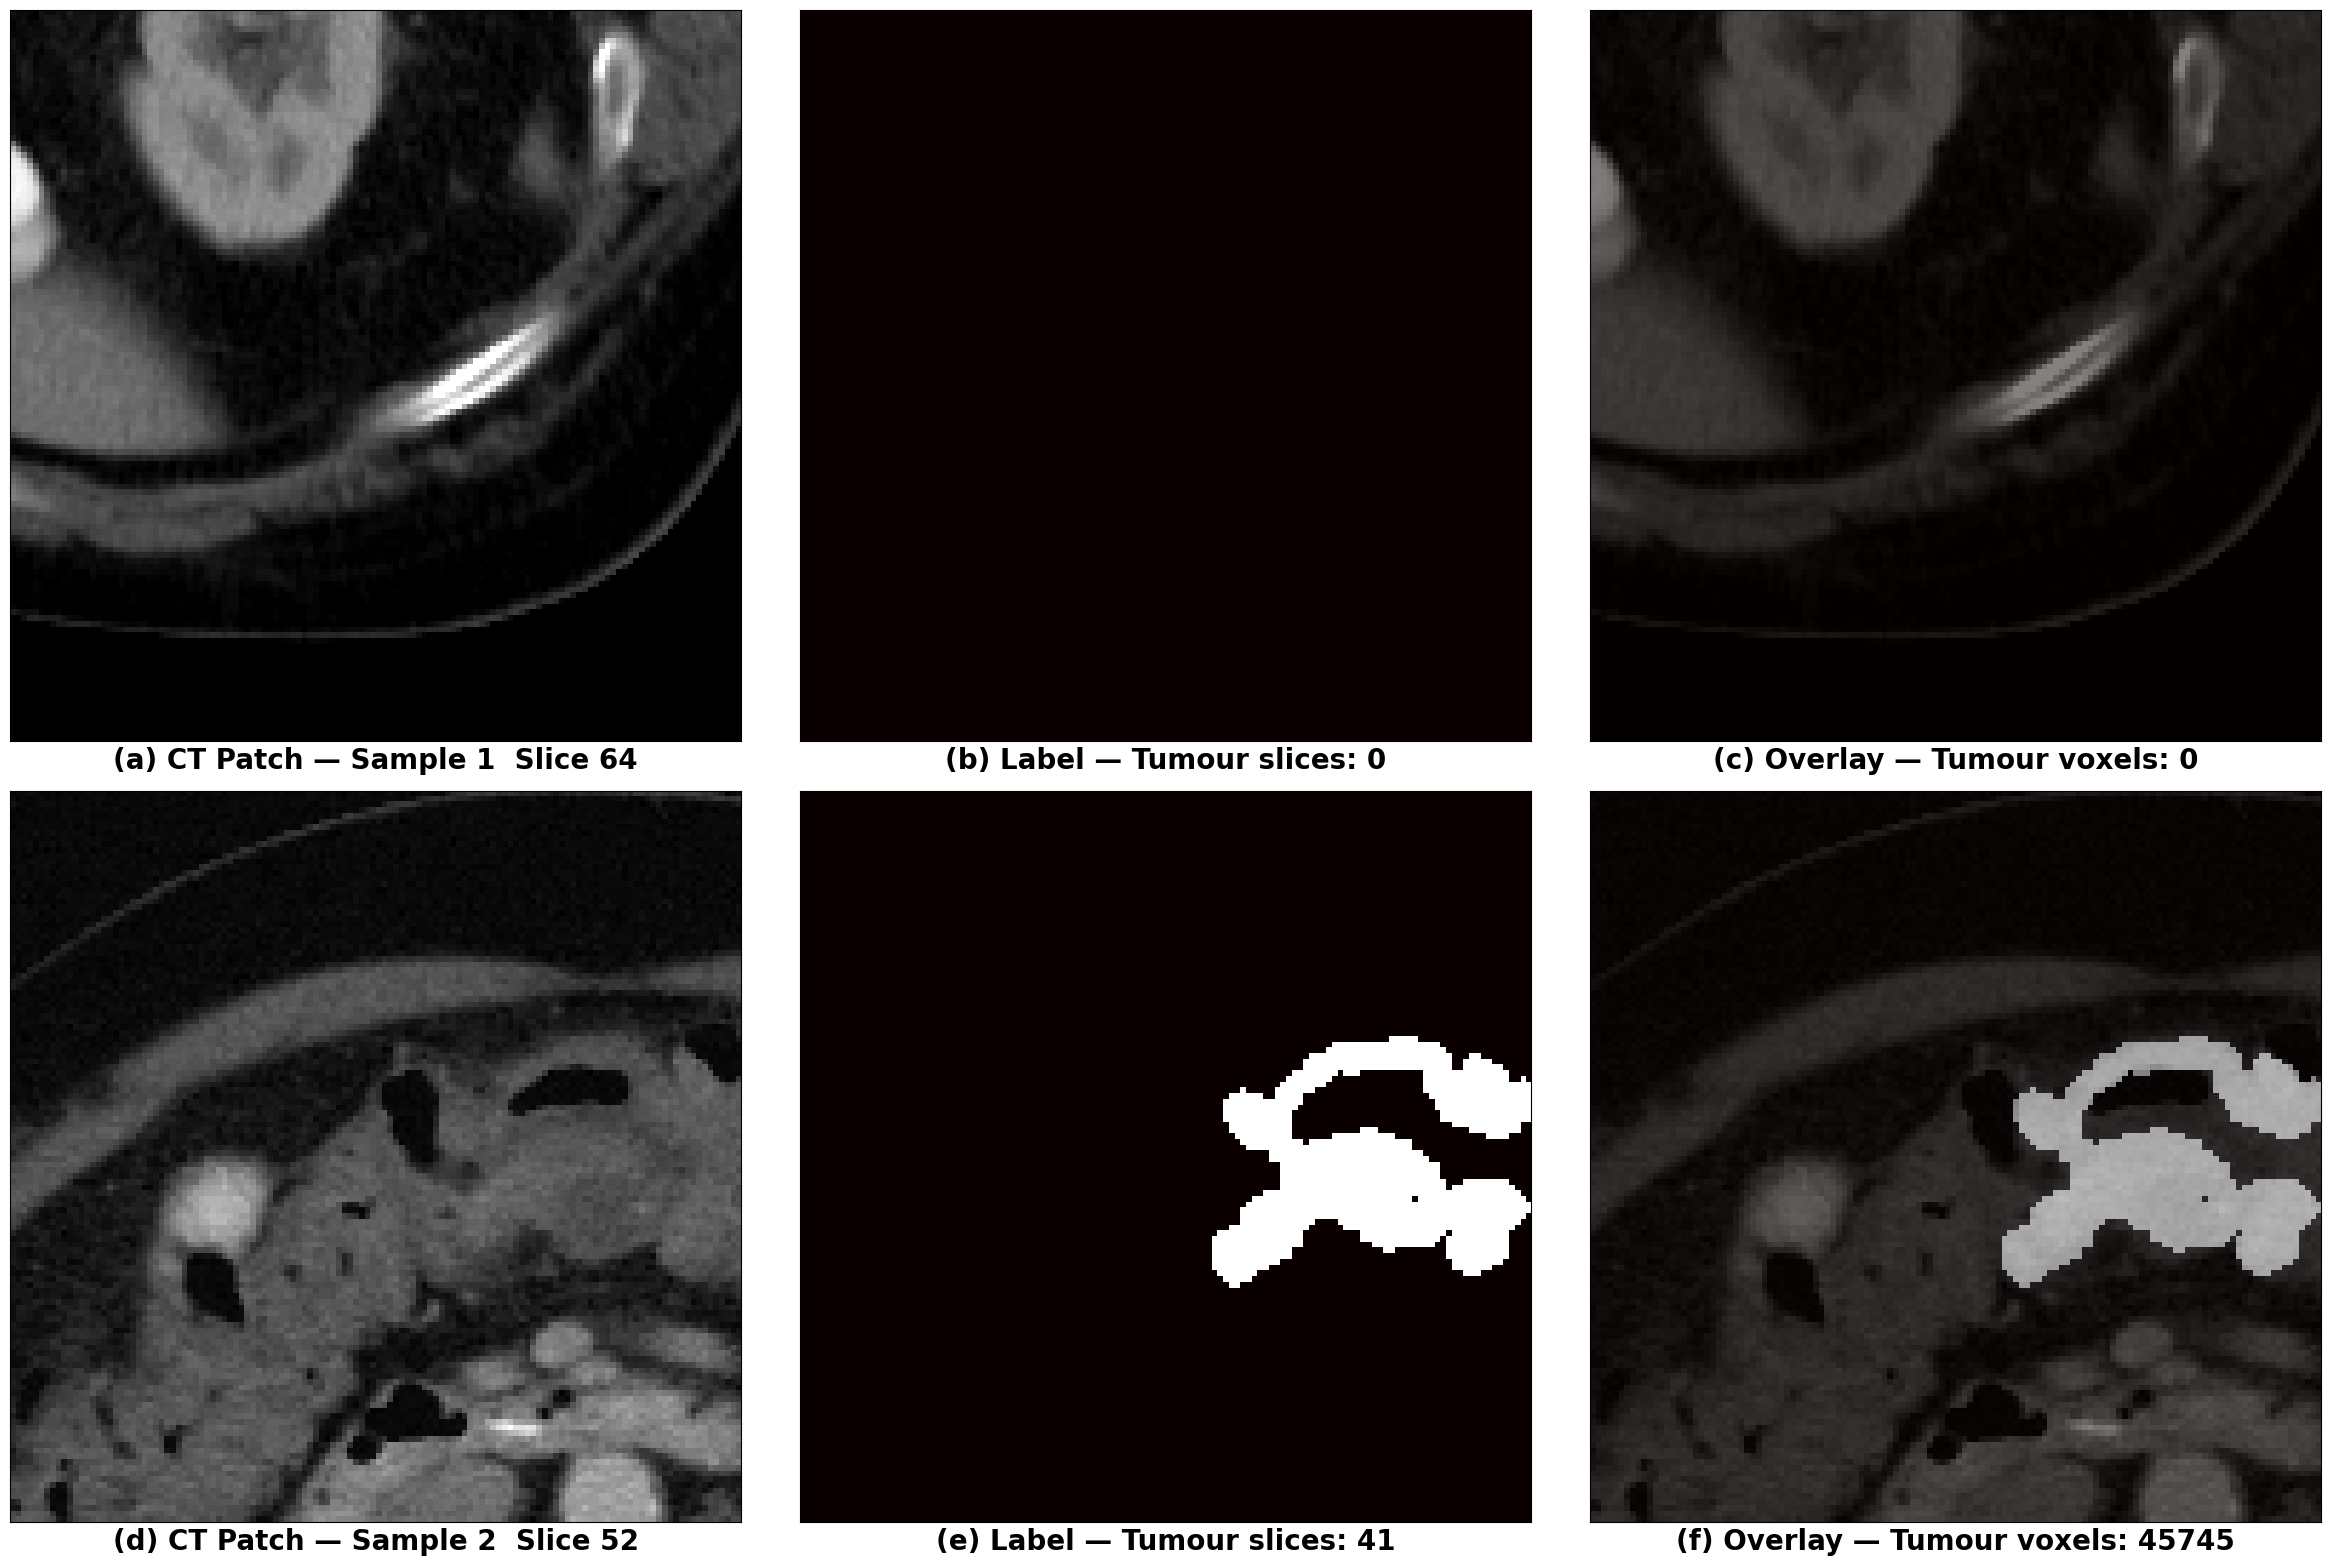

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

panel_labels = [['a','b','c'],['d','e','f']]

for row in range(2):
    img = img_batch[row, 0].numpy()
    lbl = lbl_batch[row, 0].numpy()
    t_slices = [i for i in range(lbl.shape[2]) if np.any(lbl[:,:,i] == 1)]
    mid = t_slices[len(t_slices)//2] if t_slices else 64

    axes[row, 0].imshow(img[:,:,mid], cmap='gray')
    axes[row, 0].set_xlabel(
        f'({panel_labels[row][0]}) CT Patch — Sample {row+1}  Slice {mid}',
        fontweight='bold', fontsize=FONT_SIZE)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

    axes[row, 1].imshow(lbl[:,:,mid], cmap='hot')
    axes[row, 1].set_xlabel(
        f'({panel_labels[row][1]}) Label — Tumour slices: {len(t_slices)}',
        fontweight='bold', fontsize=FONT_SIZE)
    axes[row, 1].set_xticks([]); axes[row, 1].set_yticks([])

    axes[row, 2].imshow(img[:,:,mid], cmap='gray')
    axes[row, 2].imshow(lbl[:,:,mid], cmap='hot', alpha=0.5)
    axes[row, 2].set_xlabel(
        f'({panel_labels[row][2]}) Overlay — Tumour voxels: {int(lbl.sum())}',
        fontweight='bold', fontsize=FONT_SIZE)
    axes[row, 2].set_xticks([]); axes[row, 2].set_yticks([])

fig.tight_layout()
save_fig(fig, 'fig1_training_batch.png')
plt.show()

## Fig 2 – Tumour-centred vs random patch comparison (4-panel)

Saved → conference_figures_dataset\fig2_patch_sampling_comparison.png


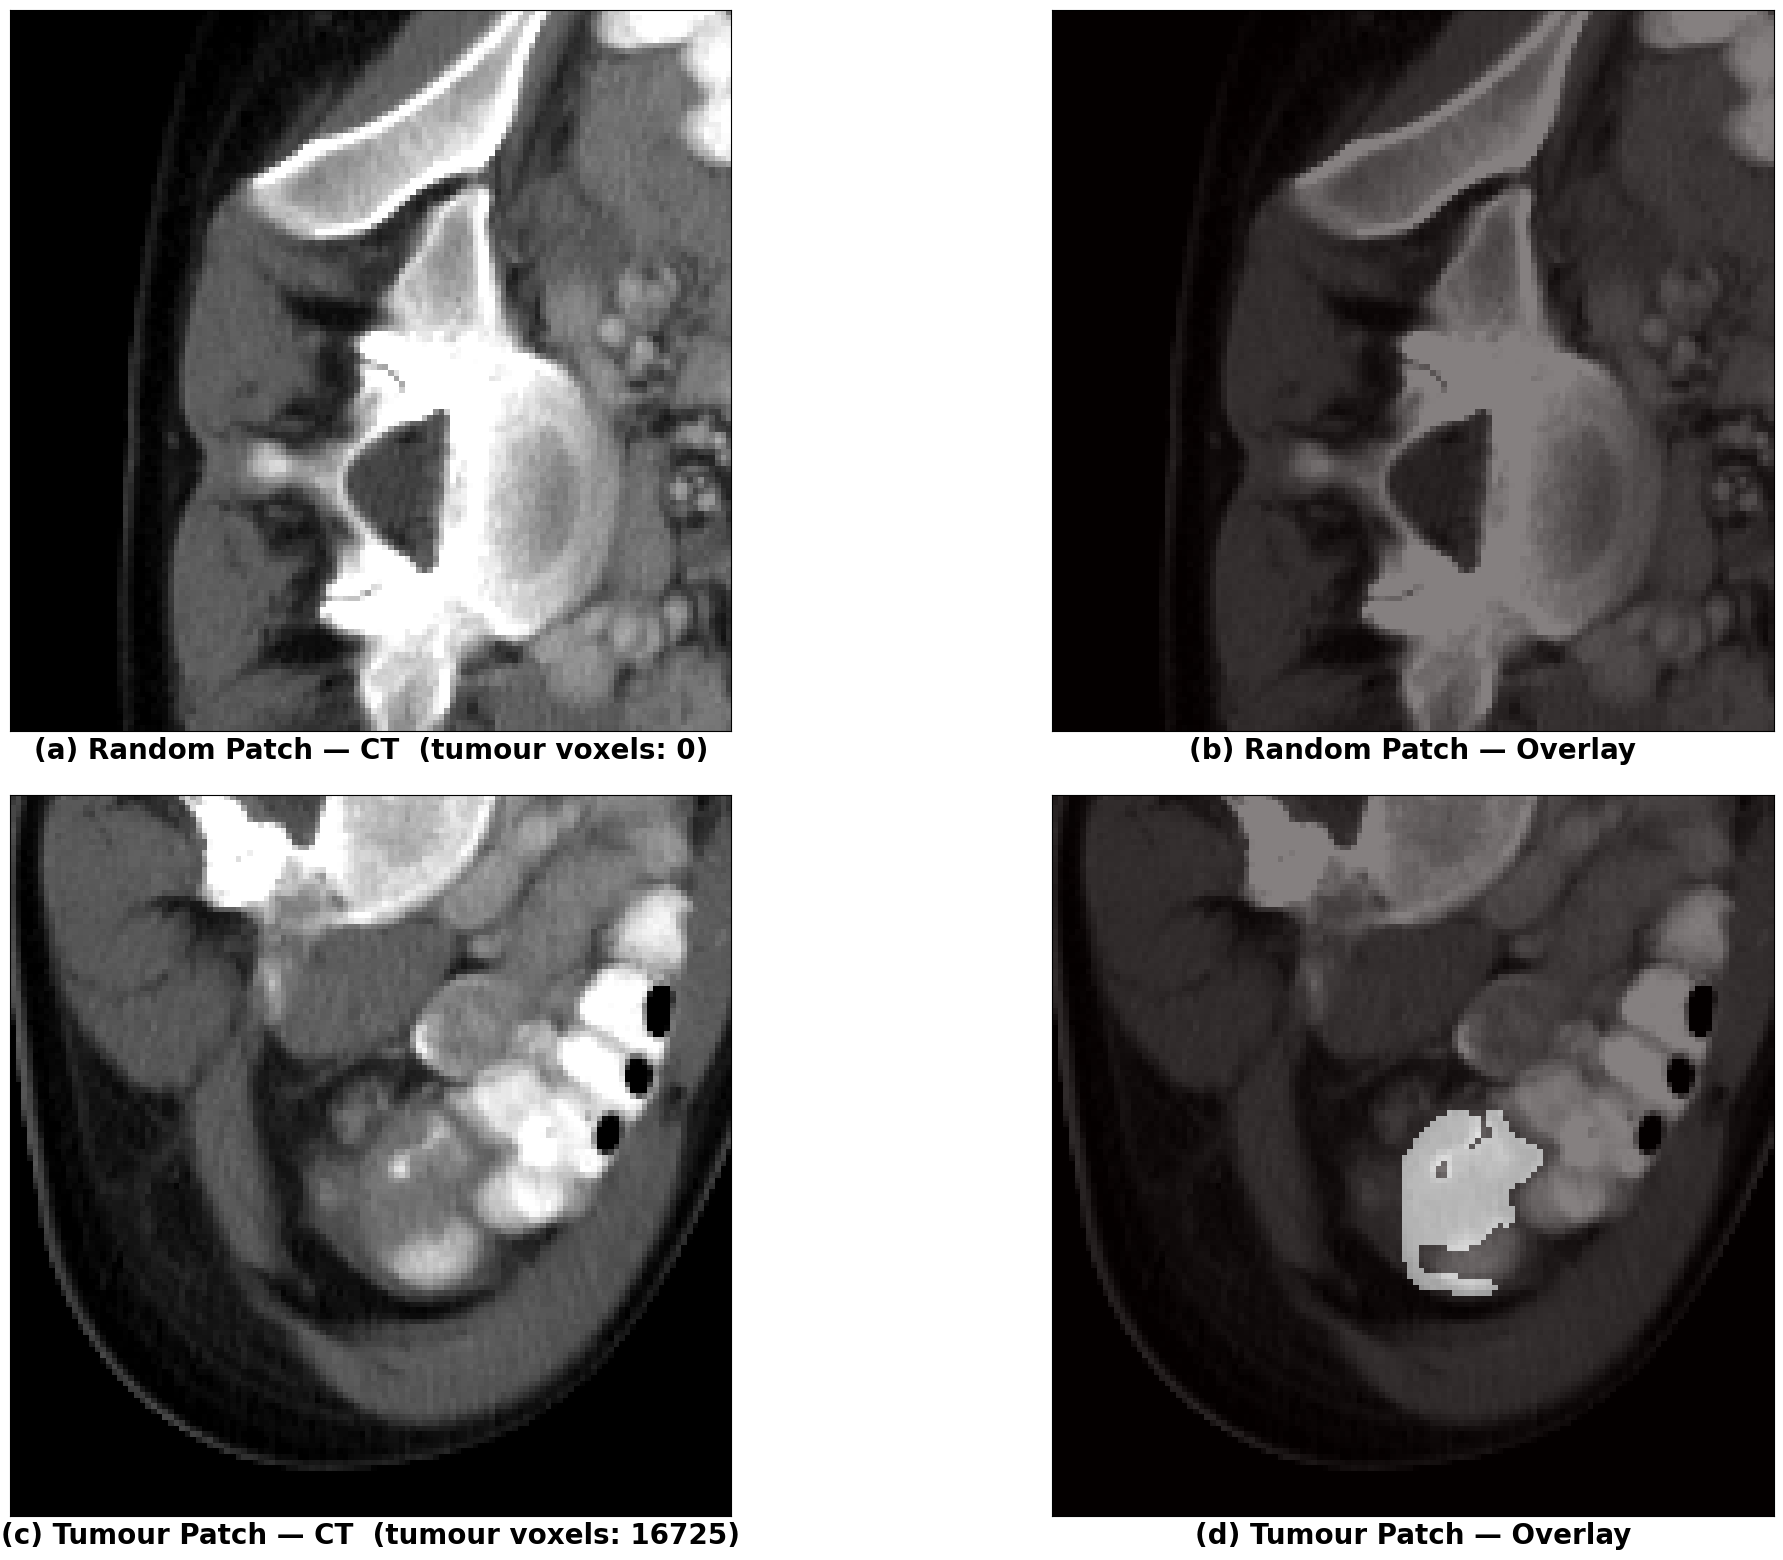

In [14]:
# Extract both patch types from the same volume for comparison
cmp_img = nib.load(os.path.join(save_dir_imgs, train_imgs[0])).get_fdata()
cmp_lbl = nib.load(os.path.join(save_dir_lbls, train_lbls[0])).get_fdata()
cmp_img, cmp_lbl = pad_if_needed(cmp_img, cmp_lbl)

rnd_i, rnd_l   = get_random_patch(cmp_img, cmp_lbl)
tum_i, tum_l   = get_tumor_patch (cmp_img, cmp_lbl)

def mid_tumor(lbl):
    sl = [i for i in range(lbl.shape[2]) if np.any(lbl[:,:,i] == 1)]
    return sl[len(sl)//2] if sl else lbl.shape[2]//2

fig, axes = plt.subplots(2, 2, figsize=(24, 16))

# Random patch row
axes[0,0].imshow(rnd_i[:,:, mid_tumor(rnd_l)], cmap='gray')
axes[0,0].set_xlabel(f'(a) Random Patch — CT  (tumour voxels: {int(rnd_l.sum())})',
                     fontweight='bold', fontsize=FONT_SIZE)
axes[0,0].set_xticks([]); axes[0,0].set_yticks([])

axes[0,1].imshow(rnd_i[:,:, mid_tumor(rnd_l)], cmap='gray')
axes[0,1].imshow(rnd_l[:,:, mid_tumor(rnd_l)], cmap='hot', alpha=0.5)
axes[0,1].set_xlabel(f'(b) Random Patch — Overlay',
                     fontweight='bold', fontsize=FONT_SIZE)
axes[0,1].set_xticks([]); axes[0,1].set_yticks([])

# Tumour-centred patch row
axes[1,0].imshow(tum_i[:,:, mid_tumor(tum_l)], cmap='gray')
axes[1,0].set_xlabel(f'(c) Tumour Patch — CT  (tumour voxels: {int(tum_l.sum())})',
                     fontweight='bold', fontsize=FONT_SIZE)
axes[1,0].set_xticks([]); axes[1,0].set_yticks([])

axes[1,1].imshow(tum_i[:,:, mid_tumor(tum_l)], cmap='gray')
axes[1,1].imshow(tum_l[:,:, mid_tumor(tum_l)], cmap='hot', alpha=0.5)
axes[1,1].set_xlabel(f'(d) Tumour Patch — Overlay',
                     fontweight='bold', fontsize=FONT_SIZE)
axes[1,1].set_xticks([]); axes[1,1].set_yticks([])

fig.tight_layout()
save_fig(fig, 'fig2_patch_sampling_comparison.png')
plt.show()

## Fig 3 – Effect of data augmentation (8-panel)

Saved → conference_figures_dataset\fig3_augmentation_effect.png


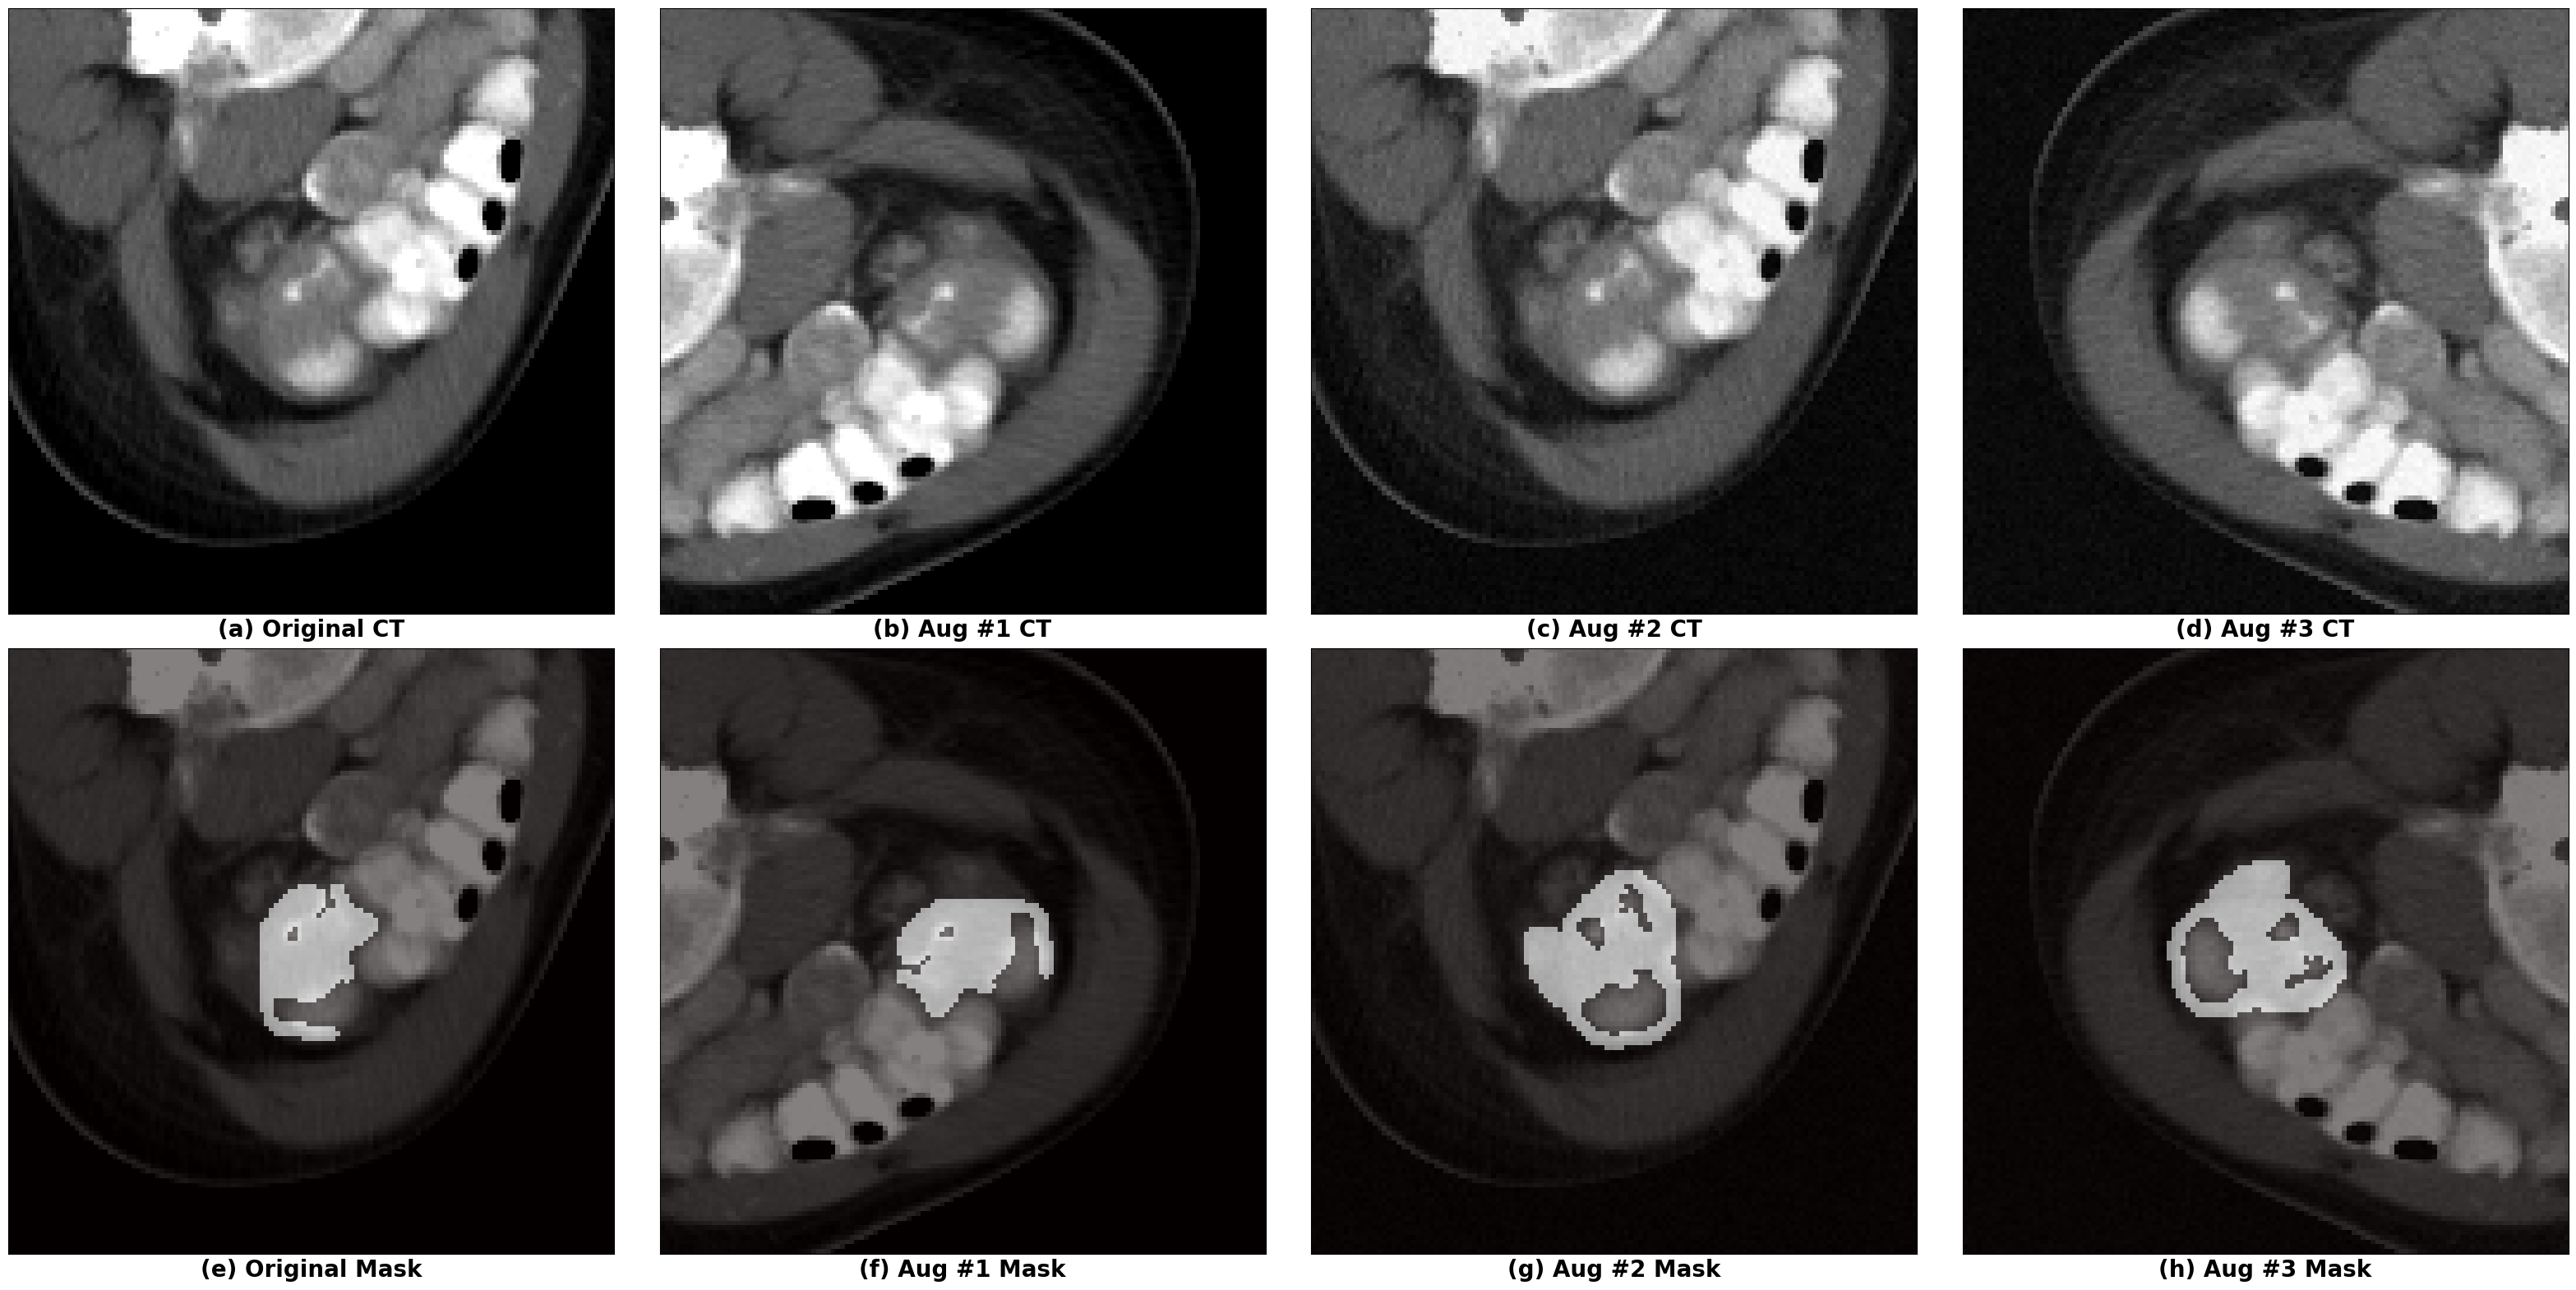

In [15]:
set_seed(0)
base_i, base_l = get_tumor_patch(cmp_img, cmp_lbl)
mid_s          = mid_tumor(base_l)

fig, axes = plt.subplots(2, 4, figsize=(32, 16))
abc = list('abcdefgh')

for col in range(4):
    if col == 0:
        ai, al = base_i.copy(), base_l.copy()
        tag_i, tag_l = 'Original CT', 'Original Mask'
    else:
        ai, al = augment_patch(base_i.copy(), base_l.copy())
        tag_i  = f'Aug #{col} CT'
        tag_l  = f'Aug #{col} Mask'

    ms = mid_tumor(al)

    axes[0, col].imshow(ai[:,:,ms], cmap='gray')
    axes[0, col].set_xlabel(f'({abc[col]}) {tag_i}',
                            fontweight='bold', fontsize=FONT_SIZE)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

    axes[1, col].imshow(ai[:,:,ms], cmap='gray')
    axes[1, col].imshow(al[:,:,ms], cmap='hot', alpha=0.5)
    axes[1, col].set_xlabel(f'({abc[col+4]}) {tag_l}',
                            fontweight='bold', fontsize=FONT_SIZE)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

fig.tight_layout()
save_fig(fig, 'fig3_augmentation_effect.png')
plt.show()

## Fig 4 – Tumour voxel distribution: train vs validation (2-panel)

Counting train tumour voxels...


Counting: 100%|██████████████████████████████████████████████████████████████████████| 100/100 [00:41<00:00,  2.44it/s]


Counting val tumour voxels...


Counting: 100%|████████████████████████████████████████████████████████████████████████| 26/26 [00:11<00:00,  2.31it/s]


Saved → conference_figures_dataset\fig4_tumour_split_distribution.png


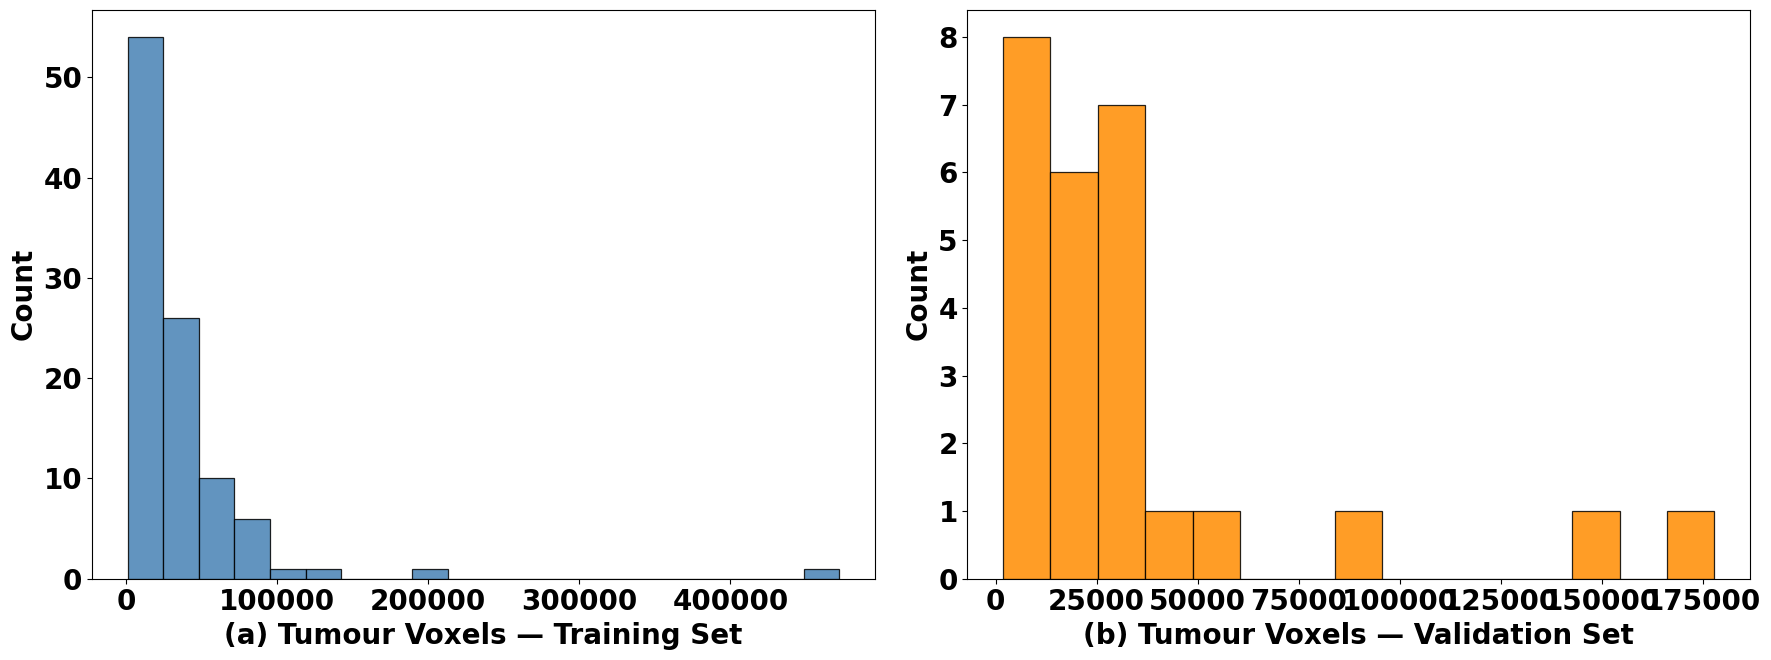

Train — min:1165  max:471903  mean:37110
Val   — min:1852    max:177759    mean:33291


In [16]:
def count_tumor_voxels(flist, lbl_dir):
    counts = []
    for f in tqdm(flist, desc='Counting'):
        lbl = nib.load(os.path.join(lbl_dir, f)).get_fdata()
        counts.append(int(np.sum(lbl == 1)))
    return np.array(counts)

print("Counting train tumour voxels...")
train_tv = count_tumor_voxels(train_lbls, save_dir_lbls)
print("Counting val tumour voxels...")
val_tv   = count_tumor_voxels(val_lbls,   save_dir_lbls)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].hist(train_tv, bins=20, color='steelblue', edgecolor='black', linewidth=0.9, alpha=0.85)
axes[0].set_xlabel('(a) Tumour Voxels — Training Set',   fontweight='bold', fontsize=FONT_SIZE)
axes[0].set_ylabel('Count',                              fontweight='bold', fontsize=FONT_SIZE)
make_bold_ticks(axes[0])

axes[1].hist(val_tv,   bins=15, color='darkorange', edgecolor='black', linewidth=0.9, alpha=0.85)
axes[1].set_xlabel('(b) Tumour Voxels — Validation Set', fontweight='bold', fontsize=FONT_SIZE)
axes[1].set_ylabel('Count',                              fontweight='bold', fontsize=FONT_SIZE)
make_bold_ticks(axes[1])

fig.tight_layout()
save_fig(fig, 'fig4_tumour_split_distribution.png')
plt.show()

print(f"Train — min:{train_tv.min()}  max:{train_tv.max()}  mean:{train_tv.mean():.0f}")
print(f"Val   — min:{val_tv.min()}    max:{val_tv.max()}    mean:{val_tv.mean():.0f}")

## Fig 5 – Patch sampling strategy summary (bar chart)

Saved → conference_figures_dataset\fig5_patch_sampling_strategy.png


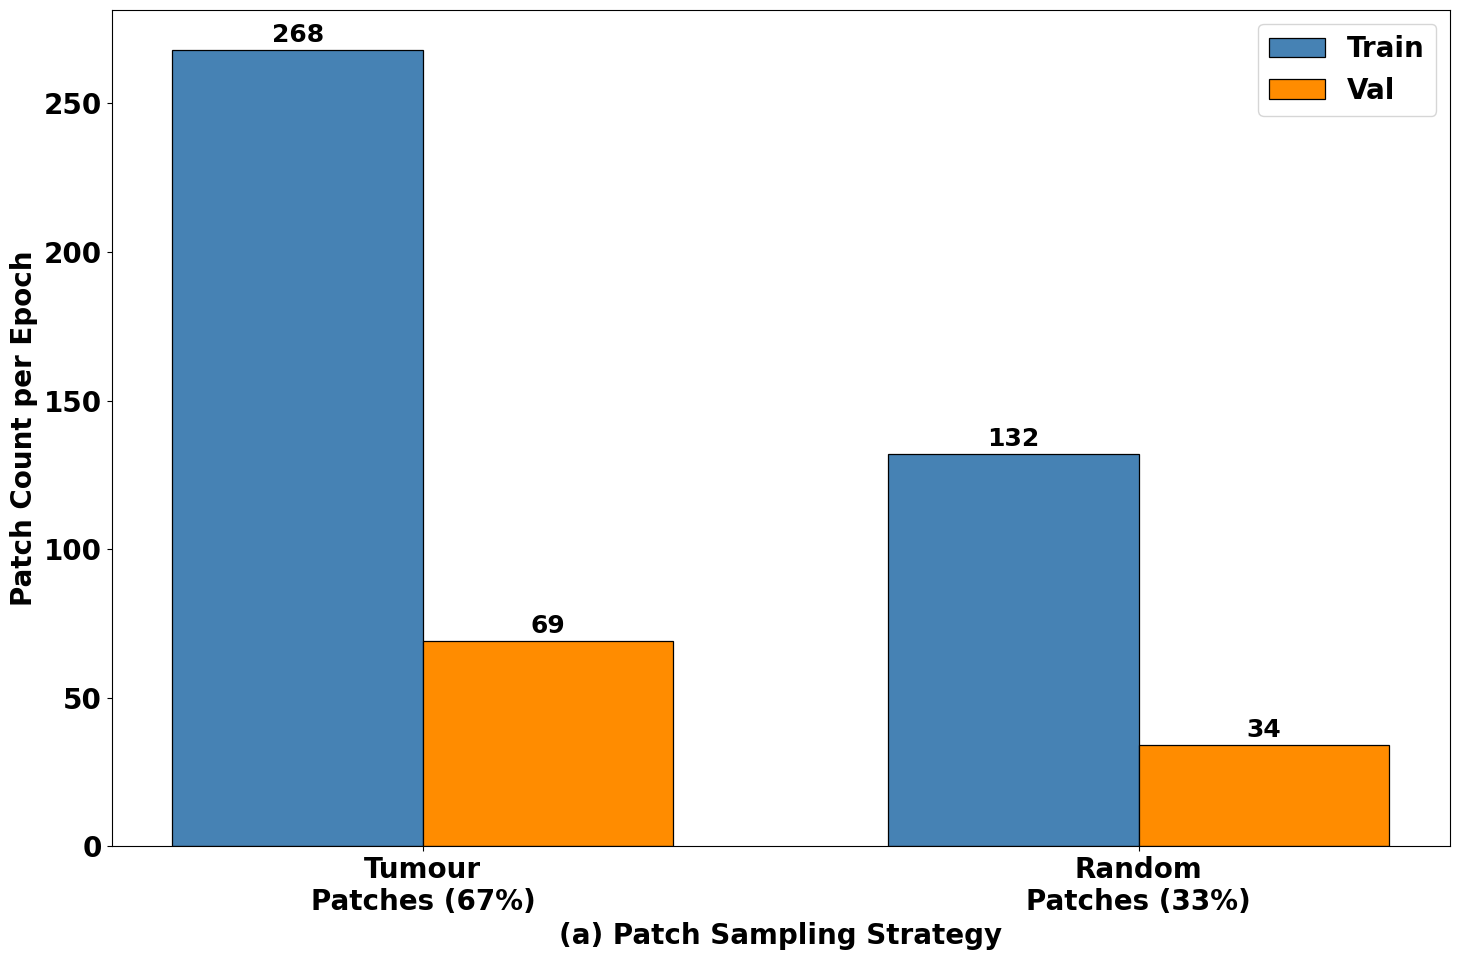

In [17]:
categories  = ['Tumour\nPatches (67%)', 'Random\nPatches (33%)']
train_counts = [int(len(train_dataset) * 0.67), int(len(train_dataset) * 0.33)]
val_counts   = [int(len(val_dataset)   * 0.67), int(len(val_dataset)   * 0.33)]

x      = np.arange(len(categories))
width  = 0.35

fig, ax = plt.subplots(figsize=(15, 10))
bars1 = ax.bar(x - width/2, train_counts, width, color='steelblue',
               edgecolor='black', linewidth=0.9, label='Train')
bars2 = ax.bar(x + width/2, val_counts,   width, color='darkorange',
               edgecolor='black', linewidth=0.9, label='Val')

ax.set_xlabel('(a) Patch Sampling Strategy', fontweight='bold', fontsize=FONT_SIZE)
ax.set_ylabel('Patch Count per Epoch',       fontweight='bold', fontsize=FONT_SIZE)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontweight='bold', fontsize=FONT_SIZE)
make_bold_ticks(ax)

leg = ax.legend(fontsize=FONT_SIZE)
for t in leg.get_texts():
    t.set_fontweight('bold')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontweight='bold', fontsize=FONT_SIZE-2)

fig.tight_layout()
save_fig(fig, 'fig5_patch_sampling_strategy.png')
plt.show()

## Dataset notebook — final summary

In [18]:
print("=" * 60)
print("DATASET NOTEBOOK — COMPLETE SUMMARY")
print("=" * 60)

print(f"\n STEPS COMPLETED")
print(f"   1. Train/val split : 100 train / {len(val_imgs)} val")
print(f"   2. Patch size      : 128x128x128")
print(f"   3. Tumour sampling : 67% tumour-centred / 33% random")
print(f"   4. Augmentation    : flips, rot90, intensity scale/shift, Gaussian noise")
print(f"   5. DataLoader      : batch=2 train / batch=1 val")

print(f"\n DATASET STATISTICS")
print(f"   Train patches/epoch : {len(train_dataset)}")
print(f"   Val patches/epoch   : {len(val_dataset)}")
print(f"   Train batches       : {len(train_loader)}")
print(f"   Val batches         : {len(val_loader)}")

print(f"\n FIGURES SAVED TO  {os.path.abspath(OUTPUT_DIR)}/")
for fn in ['fig1_training_batch.png',
           'fig2_patch_sampling_comparison.png',
           'fig3_augmentation_effect.png',
           'fig4_tumour_split_distribution.png',
           'fig5_patch_sampling_strategy.png']:
    print(f"   {fn}")
print("=" * 60)

DATASET NOTEBOOK — COMPLETE SUMMARY

 STEPS COMPLETED
   1. Train/val split : 100 train / 26 val
   2. Patch size      : 128x128x128
   3. Tumour sampling : 67% tumour-centred / 33% random
   4. Augmentation    : flips, rot90, intensity scale/shift, Gaussian noise
   5. DataLoader      : batch=2 train / batch=1 val

 DATASET STATISTICS
   Train patches/epoch : 400
   Val patches/epoch   : 104
   Train batches       : 200
   Val batches         : 104

 FIGURES SAVED TO  C:\Users\DYPIU\Downloads\COLON\conference_figures_dataset/
   fig1_training_batch.png
   fig2_patch_sampling_comparison.png
   fig3_augmentation_effect.png
   fig4_tumour_split_distribution.png
   fig5_patch_sampling_strategy.png
